> **Data required:** This notebook uses InSight HP³ data from Spohn et al. (2024). 
> If you haven't already, download the datasets from [FigShare](https://doi.org/10.6084/m9.figshare.25099754) 
> and place them in `resources/data/`. See [`resources/data/README.md`](../resources/data/README.md) for details.

## Introduction to Spatial Averaging

---

### The Measurement Model Problem

In the previous section we recovered a single thermal diffusivity κ = 4.19 × 10⁻⁸ m²/s by treating the HP³ mole as a point sensor at a representative depth of 9.4 cm. This matched Spohn et al.'s published value to within 7%, independently validating their result using a physics-informed neural network. However, the mole signal fit remained poor (RMSE = 2.63 K) with a persistent phase lag between the PINN prediction and the TEM-A data.

The question we now address: **is the mole signal mismatch a network limitation, or a forward model limitation?**

### Why the Point-Sensor Model Breaks Down

The HP³ mole is not a point thermometer. It is a 40 cm aluminum cylinder (thermal conductivity k_Al ≈ 200 W/m·K) buried at 30° inclination, spanning depths z₀ = 1.7 cm to z₁ = 36.3 cm. Because aluminum conducts heat roughly 5000× faster than the surrounding Martian soil (k_soil ≈ 0.039 W/m·K), the mole is **nearly isothermal** along its entire length. The TEM-A sensor, a 31.5 cm copper-on-Kapton foil wrapped along the hull, therefore records the equilibrium temperature of the aluminum body — not the soil temperature at any single depth.

This equilibrium temperature is set by the condition that the net heat flux into the mole vanishes:

$$\int_{z_0}^{z_1} k_{\text{soil}} \left[ T_{\text{soil}}(z, t) - T_{\text{mole}}(t) \right] dz = 0$$

For approximately uniform k_soil, this gives:

$$T_{\text{mole}}(t) = \frac{1}{z_1 - z_0} \int_{z_0}^{z_1} T_{\text{soil}}(z, t) \, dz$$

The mole temperature is the **spatial mean** of the undisturbed soil temperature over its depth extent.

### Why the Representative Depth is Frequency-Dependent

Spohn et al. report representative depths of 9.4 cm (diurnal) and 16.3 cm (annual). These are not physical locations on the mole — they are the depths at which a hypothetical point sensor would reproduce the same amplitude ratio and phase lag as the spatially-averaged mole signal, **for a single frequency component only**.

The diurnal thermal skin depth is δ₁ = √(κP/π) ≈ 3.3 cm. Higher harmonics decay faster: δₙ = δ₁/√n. When the mole spatially averages a signal whose decay rate depends on frequency, the effective measurement depth differs for each Fourier component. A single representative depth cannot capture the full waveform — it is valid only for the first harmonic.

### Implementation

We discretise the spatial average using N = 100 depth points uniformly spaced from z₀ to z₁:

$$\hat{T}_{\text{mole}}(t_i) = \frac{1}{N} \sum_{j=1}^{N} T_{\text{net}}(z_j, t_i)$$

The data loss becomes:

$$\mathcal{L}_{\text{data}} = \frac{1}{M} \sum_{i=1}^{M} \left| \hat{T}_{\text{mole}}(t_i) - T_{\text{data}}(t_i) \right|^2$$

The boundary condition loss and physics loss remain unchanged. The only modification is replacing a single network evaluation per data point with an average over 100 evaluations.

| Symbol | Meaning | Value |
|--------|---------|-------|
| z₀ | Depth to back-end of mole | 1.7 cm |
| z₁ | Depth to tip of mole | 36.3 cm |
| N | Number of spatial quadrature points | 100 |
| δ₁ | Diurnal skin depth | ~3.3 cm |
| T_net(z, t) | PINN temperature prediction | Learned |
| κ | Thermal diffusivity (learnable) | Initialised at 3.93 × 10⁻⁸ m²/s |

---



In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 1e-7       # thermal diffusivity [m^2/s]. We will learn this parameter.
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
z0 = 0.017
z1 = 0.363
N = 100



# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# Now each data point will be calculated using the spatial average of the sensor.

# Space out the depths in N equal slices.
x_depths = jnp.linspace(z0, z1, N).reshape(-1, 1)

t_data = jnp.array(ltst_mole).reshape(-1, 1)
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_depths = normalize_x(x_depths)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, tx_all, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss

        # One forward pass, reshape, average
        preds = network(params, tx_all)           # (M*100, 1)
        preds = preds.reshape(-1, N)             # (M, 100)
        avg_preds = jnp.mean(preds, axis=1, keepdims=True)  # (M, 1)
        data_loss = jnp.mean((avg_preds - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 200, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 120000
save_every = 1000
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()


# Build (M*100, 2) tensor in one go
t_repeated = jnp.repeat(t_data, N, axis=0)      # each tᵢ repeated 100 times
x_tiled = jnp.tile(x_depths, (len(t_data), 1))  # depths tiled M times
tx_all = jnp.concatenate([t_repeated, x_tiled], axis=1)


# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        tx_all, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


import pickle

checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
}

with open('checkpoints_perturbance/run01.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")

/usr/local/lib/python3.12/dist-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/120000, Loss: 2.568501
  BC Loss: 0.023559, Physics Loss: 0.187560, Data Loss: 0.000125
  Current kappa: 1.02e-07 m^2/s
Iteration 2000/120000, Loss: 0.928511
  BC Loss: 0.008527, Physics Loss: 0.058287, Data Loss: 0.000087
  Current kappa: 1.02e-07 m^2/s
Iteration 3000/120000, Loss: 0.257524
  BC Loss: 0.002074, Physics Loss: 0.036757, Data Loss: 0.000067
  Current kappa: 1.03e-07 m^2/s
Iteration 4000/120000, Loss: 0.115042
  BC Loss: 0.000747, Physics Loss: 0.023286, Data Loss: 0.000085
  Current kappa: 1.03e-07 m^2/s
Iteration 5000/120000, Loss: 0.147257
  BC Loss: 0.000502, Physics Loss: 0.070003, Data Loss: 0.000135
  Current kappa: 1.03e-07 m^2/s
Iteration 6000/120000, Loss: 0.056925
  BC Loss: 0.000377, Physics Loss: 0.003932, Data Loss: 0.000077
  Current kappa: 1.03e-07 m^2/s
Iteration 7000/120000, Loss: 0.078576
  BC Loss: 0.000363, Physics Loss: 0.026441, Data Loss: 0.000079
  Current kappa: 1.03e-07 m^2/s
Iteration 8000/120000, Loss: 0.051513
  BC Loss: 0.0002

In [ ]:
import pickle

with open('checkpoints/inverse_run06.pkl', 'rb') as f:
    ckpt = pickle.load(f)

params = ckpt['params']
losses = ckpt['losses']
losses_bc = ckpt['losses_bc']
losses_phys = ckpt['losses_phys']
losses_data = ckpt['losses_data']
snapshots = ckpt['snapshots']
snapshot_iterations = ckpt['snapshot_iterations']

## Loss curves

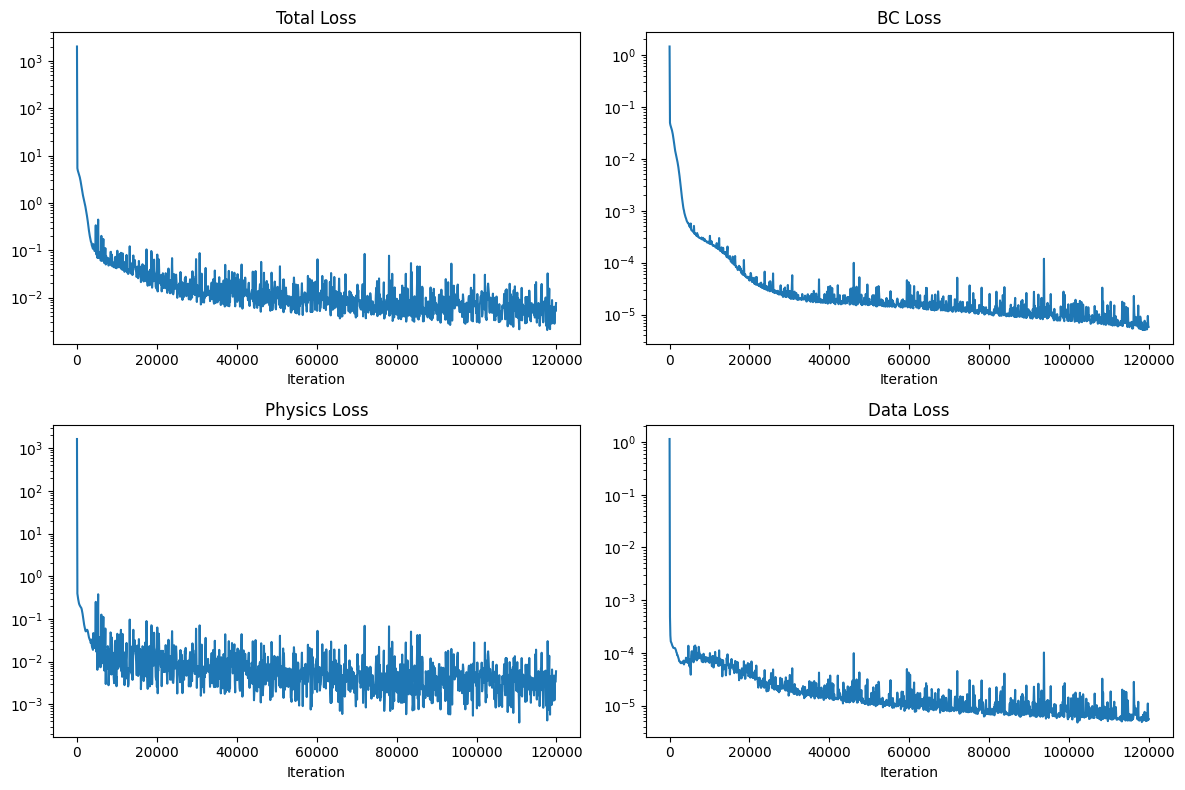

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Subsample every 100th point for faster plotting
step = 100
iters = np.arange(0, len(losses), step)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].semilogy(iters, [losses[i] for i in iters])
axes[0,0].set_title('Total Loss')
axes[0,0].set_xlabel('Iteration')

axes[0,1].semilogy(iters, [losses_bc[i] for i in iters])
axes[0,1].set_title('BC Loss')
axes[0,1].set_xlabel('Iteration')

axes[1,0].semilogy(iters, [losses_phys[i] for i in iters])
axes[1,0].set_title('Physics Loss')
axes[1,0].set_xlabel('Iteration')

axes[1,1].semilogy(iters, [losses_data[i] for i in iters])
axes[1,1].set_title('Data Loss')
axes[1,1].set_xlabel('Iteration')

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150)
plt.show()

## Compare PINN with Data

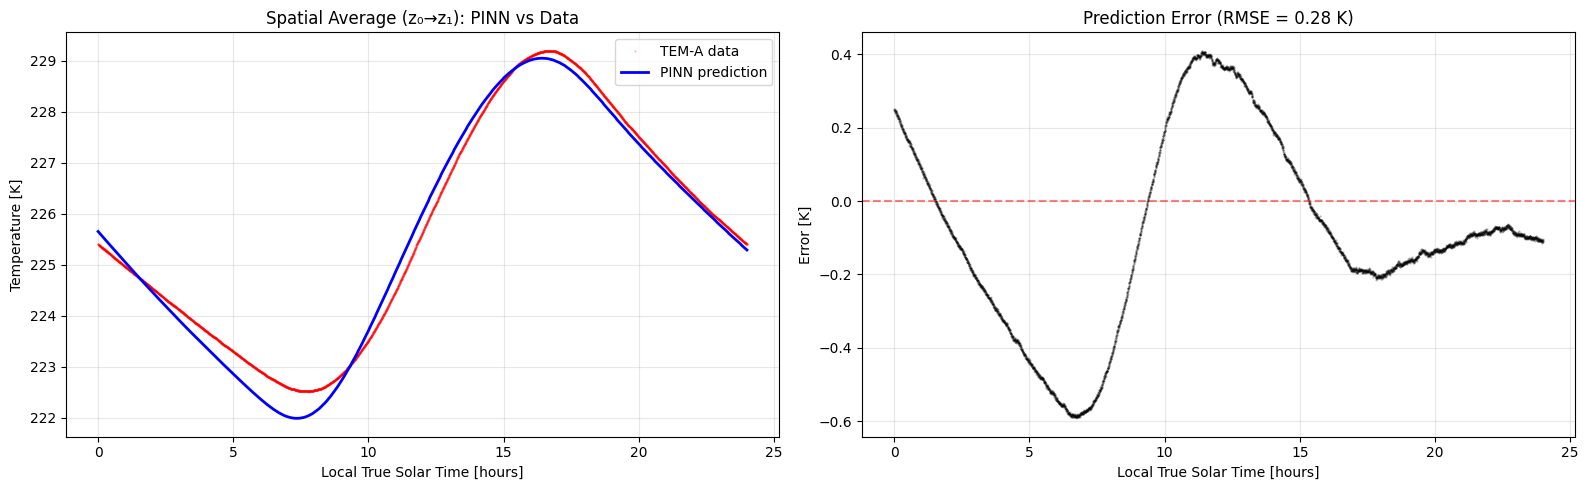

In [ ]:
# Problem parameters
kappa = 1e-8       # thermal diffusivity [m^2/s]. We will learn this parameter.
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
z0 = 0.017
z1 = 0.363
N = 100

# ============================================================
# Plot: Network prediction vs TEM-A data at mole depth
# ============================================================

# Create a dense time array (normalised)
t_plot = jnp.linspace(0, 1, 500).reshape(-1, 1)  # (500, 1)

# Build the same spatial average as in training
t_repeated_plot = jnp.repeat(t_plot, N, axis=0)          # (500*100, 1)
x_tiled_plot = jnp.tile(x_depths, (len(t_plot), 1))      # (500*100, 1)
tx_plot = jnp.concatenate([t_repeated_plot, x_tiled_plot], axis=1)  # (500*100, 2)

# Forward pass, reshape, average over depths
u_pred_norm = network(params, tx_plot)        # (50000, 1)
u_pred_norm = u_pred_norm.reshape(-1, N)      # (500, 100)
u_pred_avg = jnp.mean(u_pred_norm, axis=1)   # (500,)

# Convert back to physical units
t_plot_hours = np.array(t_plot.ravel()) * 24
u_pred_K = np.array(unnormalize_u(u_pred_avg))

# Also convert mole data back to hours for comparison
t_mole_hours = np.array(ltst_mole) * 24 / sol_seconds * (24/24)
# Actually ltst_mole is already in seconds (converted earlier), so:
t_mole_hours = np.array(ltst_mole) / sol_seconds * 24  # seconds -> LTST hours
u_mole_K = np.array(temp_mole)  # already in Kelvin

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: overlay prediction and data
ax1 = axes[0]
ax1.plot(t_mole_hours, u_mole_K, 'r.', markersize=1, alpha=0.3, label='TEM-A data')
ax1.plot(t_plot_hours, u_pred_K, 'b-', linewidth=2, label='PINN prediction')
ax1.set_xlabel('Local True Solar Time [hours]')
ax1.set_ylabel('Temperature [K]')
ax1.set_title('Spatial Average (z₀→z₁): PINN vs Data')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: error (prediction - data) over time
# Interpolate prediction to data time points for direct comparison
u_pred_at_data = np.interp(t_mole_hours, t_plot_hours, u_pred_K)
error = u_pred_at_data - u_mole_K

ax2 = axes[1]
ax2.plot(t_mole_hours, error, 'k.', markersize=1, alpha=0.3)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax2.set_xlabel('Local True Solar Time [hours]')
ax2.set_ylabel('Error [K]')
ax2.set_title(f'Prediction Error (RMSE = {np.sqrt(np.mean(error**2)):.2f} K)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Does the PINN follow the Physics

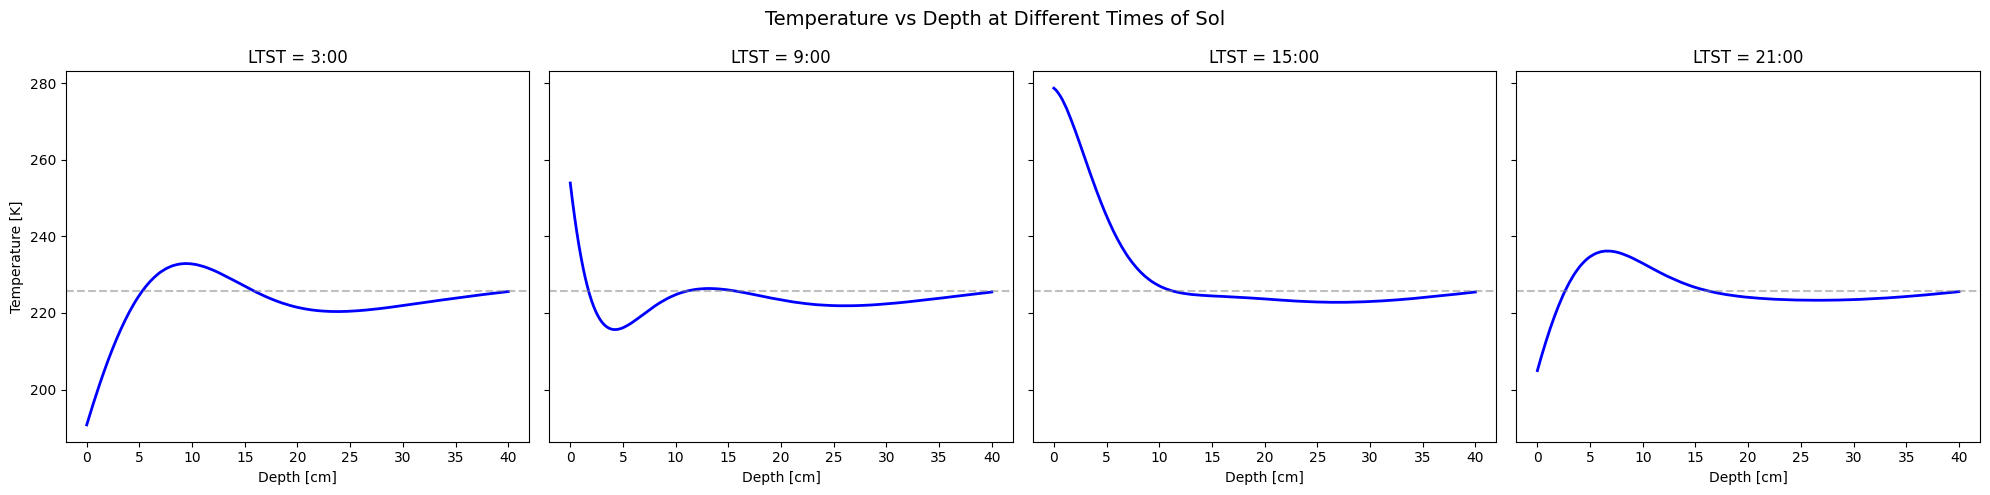

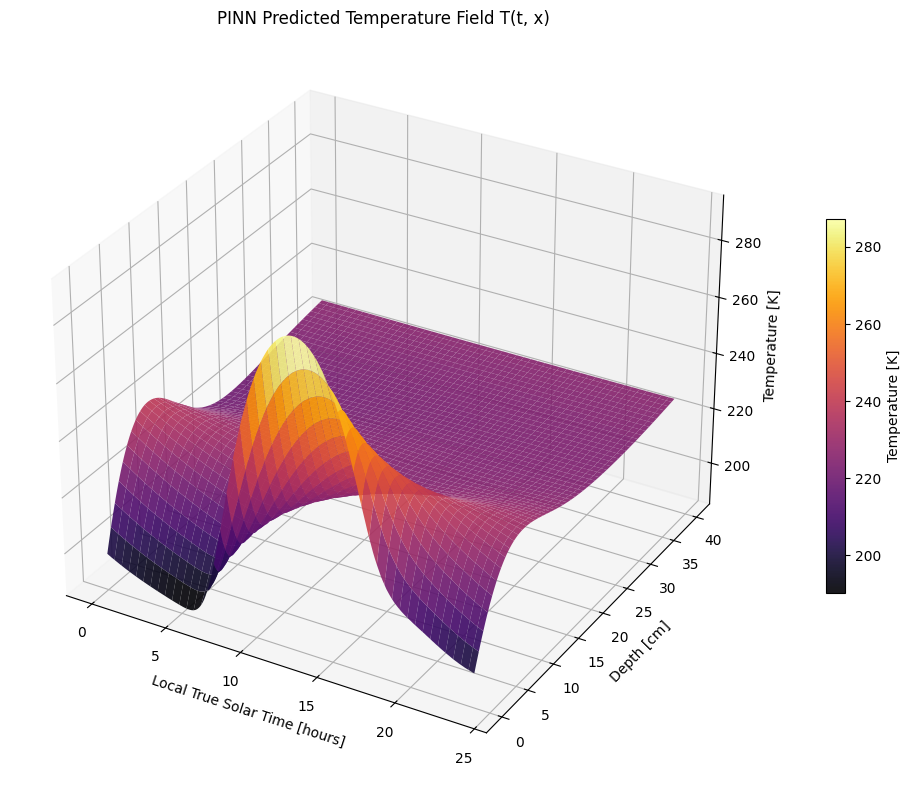

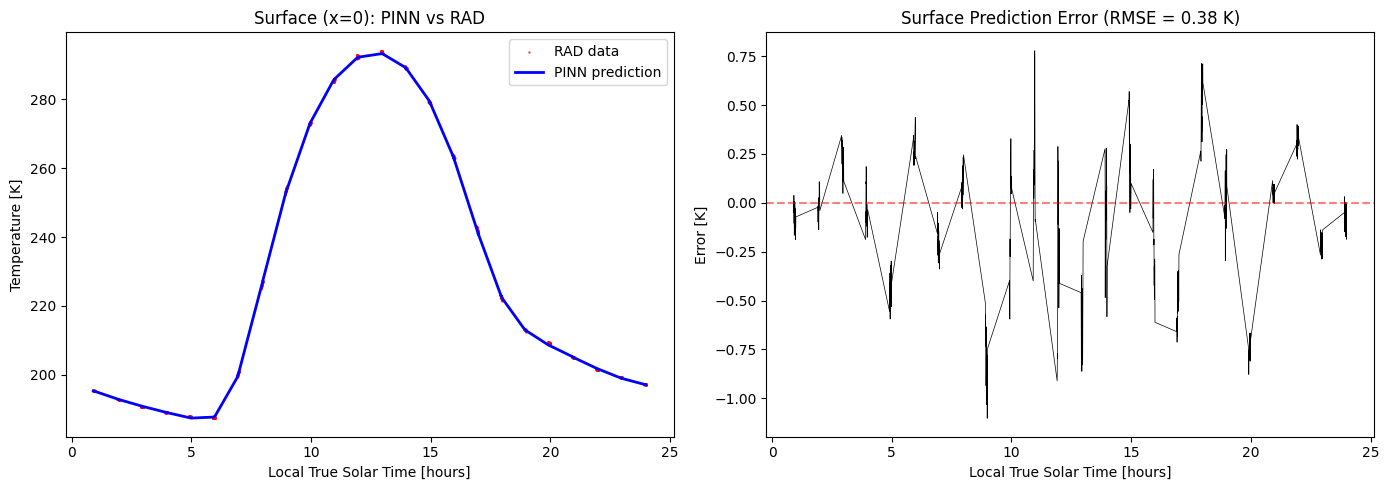

In [ ]:
# Temperature vs Depth at four times of day
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

hours_to_plot = [3, 9, 15, 21]
depths = jnp.linspace(0, depth, 200)  # 0 to 0.4 m

for idx, hour in enumerate(hours_to_plot):
    t_sec = hour * sol_seconds / 24
    t_norm = normalize_t(t_sec)
    x_norm = normalize_x(depths)

    # Build input array
    t_input = jnp.ones_like(x_norm) * t_norm
    tx_input = jnp.stack([t_input, x_norm], axis=-1)

    # Predict
    u_pred_norm = network(params, tx_input)
    u_pred = unnormalize_u(u_pred_norm.ravel())

    axes[idx].plot(depths * 100, u_pred, 'b-', linewidth=2)  # depth in cm
    axes[idx].set_title(f'LTST = {hour}:00')
    axes[idx].set_xlabel('Depth [cm]')
    axes[idx].axhline(y=avg_bottom_temp, color='gray', linestyle='--', alpha=0.5, label='Bottom BC')

axes[0].set_ylabel('Temperature [K]')
plt.suptitle('Temperature vs Depth at Different Times of Sol', fontsize=14)
plt.tight_layout()
plt.show()


# 3D surface plot: T(t, x)
from mpl_toolkits.mplot3d import Axes3D

n_t, n_x = 200, 200
t_grid = jnp.linspace(0, 1, n_t)  # already normalized
x_grid = jnp.linspace(0, 1, n_x)  # already normalized

T_mesh, X_mesh = jnp.meshgrid(t_grid, x_grid)
tx_flat = jnp.stack([T_mesh.ravel(), X_mesh.ravel()], axis=-1)

u_pred_flat = network(params, tx_flat)
u_pred_grid = unnormalize_u(u_pred_flat.reshape(n_x, n_t))

# Convert axes back to physical units for plotting
t_hours = np.linspace(0, 24, n_t)
x_cm = np.linspace(0, depth * 100, n_x)
T_plot, X_plot = np.meshgrid(t_hours, x_cm)

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(T_plot, X_plot, np.array(u_pred_grid), cmap='inferno', alpha=0.9)
ax.set_xlabel('Local True Solar Time [hours]')
ax.set_ylabel('Depth [cm]')
ax.set_zlabel('Temperature [K]')
ax.set_title('PINN Predicted Temperature Field T(t, x)')
fig.colorbar(surf, shrink=0.5, label='Temperature [K]')
plt.tight_layout()
plt.show()


# PINN vs RAD at surface (x=0)
t_surf_norm = normalize_t(jnp.array(ltst_surf))
x_surf_norm = jnp.zeros_like(t_surf_norm)
tx_surf = jnp.stack([t_surf_norm, x_surf_norm], axis=-1)

u_pred_surf = unnormalize_u(network(params, tx_surf).ravel())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ltst_hours_surf = [t * 24 / sol_seconds for t in ltst_surf]

axes[0].scatter(ltst_hours_surf, temp_surf, s=1, c='red', alpha=0.5, label='RAD data')
axes[0].plot(ltst_hours_surf, np.array(u_pred_surf), 'b-', linewidth=2, label='PINN prediction')
axes[0].set_xlabel('Local True Solar Time [hours]')
axes[0].set_ylabel('Temperature [K]')
axes[0].set_title('Surface (x=0): PINN vs RAD')
axes[0].legend()

# Error at surface
error_surf = np.array(u_pred_surf) - np.array(temp_surf)
axes[1].plot(ltst_hours_surf, error_surf, 'k-', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Local True Solar Time [hours]')
axes[1].set_ylabel('Error [K]')
rmse_surf = np.sqrt(np.mean(error_surf**2))
axes[1].set_title(f'Surface Prediction Error (RMSE = {rmse_surf:.2f} K)')

plt.tight_layout()
plt.show()

## Spatial Average Conclusions

---

### Summary of Results

| Experiment | λ_BC | λ_data | Scheduler | κ (m²/s) | Surface RMSE (K) | Mole RMSE (K) |
|---|---|---|---|---|---|---|
| Point sensor (9.4 cm) | 100 | 50 | No | 4.19 × 10⁻⁸ | 0.58 | 2.63 |
| Spatial avg | 100 | 50 | No | 7.60 × 10⁻⁸ | 0.32 | 0.42 |
| Spatial avg | 100 | 200 | No | 6.71 × 10⁻⁸ | 0.34 | 0.27 |
| Spatial avg | 100 | 500 | No | 6.40 × 10⁻⁸ | 0.59 | 0.32 |
| Spatial avg | 100 | 200 | Yes | 6.27 × 10⁻⁸ | 0.32 | 0.22 |

### What Improved

The spatial average dramatically improved the mole signal fit, reducing the RMSE from **2.63 K to 0.22 K** — a 12× improvement. The persistent phase lag between prediction and data was largely eliminated. The surface fit also improved slightly (0.58 → 0.32 K), likely because the better-constrained subsurface temperature field feeds back into the overall solution quality through the physics loss.

### The κ Discrepancy

The recovered κ consistently landed in the range 6.3–7.6 × 10⁻⁸ m²/s, roughly 1.6–1.9× Spohn's published value of 3.93 × 10⁻⁸. This was initially suspected to be an optimisation artifact (the physics residual's 1/κ form biasing the optimizer toward large κ). However, convergence basin analysis from three different initialisations showed all trajectories converging toward the same region:

| κ_init | κ_final | Direction |
|---|---|---|
| 1 × 10⁻⁸ | 2.37 × 10⁻⁸ | Rising (not converged) |
| 3.93 × 10⁻⁸ | 6.27 × 10⁻⁸ | Rose then settled |
| 1 × 10⁻⁷ | 6.87 × 10⁻⁸ | Fell |

This confirmed that the κ inflation is **not an optimisation artifact** but a genuine property of the uniform spatial average model. The analytical verification in the next section confirmed this conclusively.

### Key Insight

The spatial average correctly models the mole as an extended sensor, but the uniform weighting ignores the mole's role as a **thermal fin** that actively redistributes heat along its length. This missing physics inflates the recovered κ by a quantifiable amount. Addressing this requires either a physically-motivated weighting correction or a higher-dimensional model.

---


# Analytical Verification



### Motivation

The PINN recovered κ ≈ 6.3 × 10⁻⁸ m²/s with the spatial average model — significantly higher than Spohn's 3.93 × 10⁻⁸. Before attributing this to missing physics, we must rule out the possibility that the PINN optimizer is simply failing to find the correct minimum. We do this by computing the analytical answer with **no neural network involved**.

### Analytical Approach

The 1D heat equation with periodic surface forcing has an exact solution:

$$T(z, t) = \bar{T} + A \, e^{-z/\delta} \cos(\omega t - z/\delta)$$

where δ = √(κP/π) is the thermal skin depth. To compute the spatial average analytically, we use the complex exponential identity cos(ωt − z/δ) = Re[exp(i(ωt − z/δ))], which converts the integral into a single complex exponential:

$$\int_{z_0}^{z_1} e^{-z/\delta} \cos(\omega t - z/\delta) \, dz = \text{Re}\!\left[ e^{i\omega t} \int_{z_0}^{z_1} e^{-(1+i)z/\delta} \, dz \right]$$

The integral evaluates to:

$$C(\kappa) = \frac{\delta(1-i)}{2} \left( e^{-(1+i)z_0/\delta} - e^{-(1+i)z_1/\delta} \right)$$

The magnitude |C|/(z₁ − z₀) gives the amplitude ratio and −arg(C) gives the phase lag, both as functions of κ alone. We then find the κ that best matches the observed amplitude ratio (χ = 0.0595) and phase lag (ϕ = 1.2144 rad ≈ 4.64 hours), extracted from the TEM-A and RAD data via Fourier analysis.


/usr/local/lib/python3.12/dist-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


OBSERVED SIGNAL PROPERTIES (from FFT)
Surface amplitude (1st harmonic): 50.17 K
Mole amplitude (1st harmonic):    2.98 K
Amplitude ratio (chi):            0.0595
Phase lag:                         1.2144 rad
Phase lag:                         4.64 hours

ANALYTICAL SPATIAL AVERAGE RESULTS
Best-fit kappa (combined):      6.35e-08 m^2/s
  -> chi = 0.0579 (observed: 0.0595)
  -> phi = 1.1865 rad (observed: 1.2144 rad)

Kappa from amplitude only:      6.35e-08 m^2/s
Kappa from phase only:          6.35e-08 m^2/s
Spohn's value:                  3.93e-08 m^2/s

Spohn's kappa -> chi = 0.0409, phi = 1.2956 rad
Observed       -> chi = 0.0595, phi = 1.2144 rad


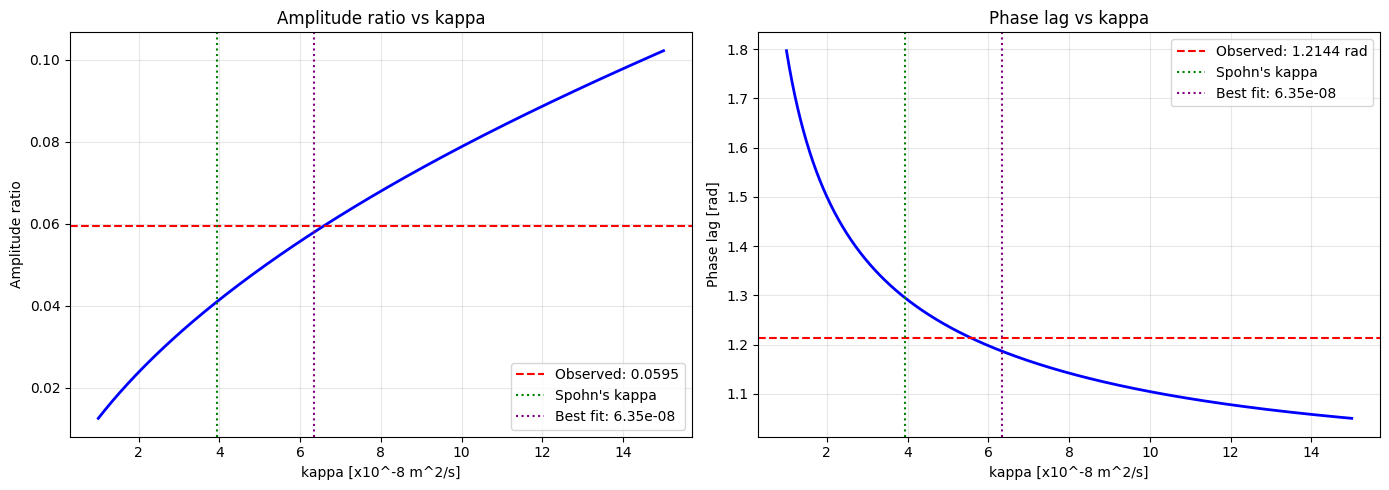

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.fft import fft, fftfreq

# ============================================================
# Step 1: Extract amplitude and phase from the real data
# ============================================================
# We need the fundamental frequency component from both signals.
# FFT is the cleanest way — it gives amplitude and phase directly.

import openpyxl

sol_seconds = 88775.244

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t * sol_seconds / 24)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass

# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t * sol_seconds / 24)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Interpolate both signals onto a common uniform time grid
# (FFT requires uniform spacing)
n_points = 2048
t_uniform = np.linspace(0, sol_seconds, n_points, endpoint=False)

temp_surf_interp = np.interp(t_uniform, ltst_surf, temp_surf)
temp_mole_interp = np.interp(t_uniform, ltst_mole, temp_mole)

# FFT of both signals
fft_surf = fft(temp_surf_interp)
fft_mole = fft(temp_mole_interp)
freqs = fftfreq(n_points, d=t_uniform[1] - t_uniform[0])

# Find the fundamental frequency (1 cycle per sol)
f_fundamental = 1.0 / sol_seconds
idx_fund = np.argmin(np.abs(freqs[:n_points//2] - f_fundamental))

# Extract amplitude and phase of fundamental
A_surf = 2.0 * np.abs(fft_surf[idx_fund]) / n_points
phi_surf = np.angle(fft_surf[idx_fund])

A_mole = 2.0 * np.abs(fft_mole[idx_fund]) / n_points
phi_mole = np.angle(fft_mole[idx_fund])

# Amplitude ratio and phase lag
chi_observed = A_mole / A_surf
phi_lag_observed = phi_surf - phi_mole  # positive = mole lags surface

# Wrap phase lag to [0, 2pi]
if phi_lag_observed < 0:
    phi_lag_observed += 2 * np.pi

print("=" * 50)
print("OBSERVED SIGNAL PROPERTIES (from FFT)")
print("=" * 50)
print(f"Surface amplitude (1st harmonic): {A_surf:.2f} K")
print(f"Mole amplitude (1st harmonic):    {A_mole:.2f} K")
print(f"Amplitude ratio (chi):            {chi_observed:.4f}")
print(f"Phase lag:                         {phi_lag_observed:.4f} rad")
print(f"Phase lag:                         {phi_lag_observed * 24 / (2*np.pi):.2f} hours")
print()

# ============================================================
# Step 2: Analytical spatial average as a function of kappa
# ============================================================
# T(z,t) = T_mean + A * exp(-z/delta) * cos(wt - z/delta)
# Spatial average = T_mean + A/(z1-z0) * Re[e^(iwt) * C(kappa)]
# where C = delta*(1-i)/2 * [exp(-(1+i)*z0/delta) - exp(-(1+i)*z1/delta)]

z0 = 0.017   # back-end depth [m]
z1 = 0.363   # tip depth [m]
P = sol_seconds
omega = 2 * np.pi / P

def spatial_average_response(kappa):
    """
    Returns (amplitude_ratio, phase_lag) for the uniform spatial
    average of the 1D analytical solution, given kappa.
    """
    delta = np.sqrt(kappa * P / np.pi)

    # Complex integration result
    F0 = np.exp(-(1 + 1j) * z0 / delta)
    F1 = np.exp(-(1 + 1j) * z1 / delta)

    C = delta * (1 - 1j) / 2 * (F0 - F1)

    # Amplitude ratio = |C| / (z1 - z0)
    chi = np.abs(C) / (z1 - z0)

    # Phase lag = -arg(C)  (negative because C multiplies e^(iwt))
    phase_lag = -np.angle(C)
    if phase_lag < 0:
        phase_lag += 2 * np.pi

    return chi, phase_lag

# ============================================================
# Step 3: Sweep kappa and find the best match
# ============================================================
kappa_range = np.linspace(1e-8, 1.5e-7, 1000)
chi_analytical = np.zeros_like(kappa_range)
phi_analytical = np.zeros_like(kappa_range)

for i, k in enumerate(kappa_range):
    chi_analytical[i], phi_analytical[i] = spatial_average_response(k)

# Find kappa that minimises combined error in amplitude ratio and phase
def objective(kappa):
    chi, phi = spatial_average_response(kappa)
    # Normalise both errors to make them comparable
    err_chi = ((chi - chi_observed) / chi_observed) ** 2
    err_phi = ((phi - phi_lag_observed) / phi_lag_observed) ** 2
    return err_chi + err_phi

result = minimize_scalar(objective, bounds=(1e-8, 1.5e-7), method='bounded')
kappa_best = result.x
chi_best, phi_best = spatial_average_response(kappa_best)

# Also find kappa from amplitude alone and phase alone
result_chi = minimize_scalar(lambda k: (spatial_average_response(k)[0] - chi_observed)**2,
                              bounds=(1e-8, 1.5e-7), method='bounded')
result_phi = minimize_scalar(lambda k: (spatial_average_response(k)[1] - phi_lag_observed)**2,
                              bounds=(1e-8, 1.5e-7), method='bounded')

print("=" * 50)
print("ANALYTICAL SPATIAL AVERAGE RESULTS")
print("=" * 50)
print(f"Best-fit kappa (combined):      {kappa_best:.2e} m^2/s")
print(f"  -> chi = {chi_best:.4f} (observed: {chi_observed:.4f})")
print(f"  -> phi = {phi_best:.4f} rad (observed: {phi_lag_observed:.4f} rad)")
print()
print(f"Kappa from amplitude only:      {result_chi.x:.2e} m^2/s")
print(f"Kappa from phase only:          {result_phi.x:.2e} m^2/s")
print(f"Spohn's value:                  3.93e-08 m^2/s")
print()

# What does Spohn's kappa predict for the spatial average?
chi_spohn, phi_spohn = spatial_average_response(3.93e-8)
print(f"Spohn's kappa -> chi = {chi_spohn:.4f}, phi = {phi_spohn:.4f} rad")
print(f"Observed       -> chi = {chi_observed:.4f}, phi = {phi_lag_observed:.4f} rad")

# ============================================================
# Step 4: Plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amplitude ratio vs kappa
axes[0].plot(kappa_range * 1e8, chi_analytical, 'b-', linewidth=2)
axes[0].axhline(y=chi_observed, color='r', linestyle='--', label=f'Observed: {chi_observed:.4f}')
axes[0].axvline(x=3.93, color='green', linestyle=':', label="Spohn's kappa")
axes[0].axvline(x=kappa_best*1e8, color='purple', linestyle=':', label=f'Best fit: {kappa_best:.2e}')
axes[0].set_xlabel('kappa [x10^-8 m^2/s]')
axes[0].set_ylabel('Amplitude ratio')
axes[0].set_title('Amplitude ratio vs kappa')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Phase lag vs kappa
axes[1].plot(kappa_range * 1e8, phi_analytical, 'b-', linewidth=2)
axes[1].axhline(y=phi_lag_observed, color='r', linestyle='--', label=f'Observed: {phi_lag_observed:.4f} rad')
axes[1].axvline(x=3.93, color='green', linestyle=':', label="Spohn's kappa")
axes[1].axvline(x=kappa_best*1e8, color='purple', linestyle=':', label=f'Best fit: {kappa_best:.2e}')
axes[1].set_xlabel('kappa [x10^-8 m^2/s]')
axes[1].set_ylabel('Phase lag [rad]')
axes[1].set_title('Phase lag vs kappa')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analytical_kappa_recovery.png', dpi=150)
plt.show()

### Result: Uniform Average

| Method | κ (m²/s) |
|---|---|
| Analytical uniform average (amplitude match) | 6.35 × 10⁻⁸ |
| Analytical uniform average (phase match) | 6.35 × 10⁻⁸ |
| PINN uniform average (best run) | 6.27 × 10⁻⁸ |
| Spohn et al. (with mole calibration) | 3.93 × 10⁻⁸ |

The analytical and PINN values agree to within 1%. **The PINN was faithfully recovering the correct κ for the model it was given.** The discrepancy with Spohn is not an optimisation failure — it is a systematic bias inherent to the uniform spatial average model.

At Spohn's true κ, the uniform average predicts χ = 0.0409 — roughly 31% lower than the observed 0.0595. The mole reads a higher amplitude than a passive spatial average of the undisturbed temperature field would predict, because the aluminum hull actively conducts heat from the warm shallow end to the cool deep end, boosting the signal.


See if weighted average can weight the gap between my value and Spohn's value.

WEIGHTED SPATIAL AVERAGE: ANALYTICAL RESULTS
Best-fit kappa: 4.96e-08 m^2/s
Best-fit alpha: 1.4 m^-1
  -> chi = 0.0595  (observed: 0.0595)
  -> phi = 1.2144 rad  (observed: 1.2144 rad)
  -> Spohn's kappa: 3.93e-08 m^2/s

1/alpha = 72.8 cm (weighting e-folding depth)
Diurnal skin depth at best kappa: 3.7 cm
Ratio alpha*delta: 0.05



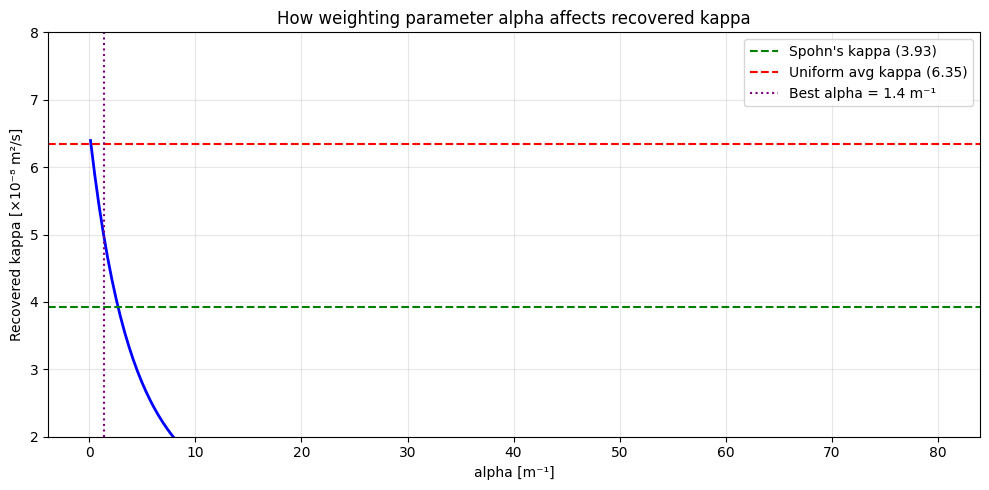

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Same observed values from previous analysis
# (paste your actual values if slightly different)
chi_observed = 0.0595
phi_observed = 1.2144  # rad

z0 = 0.017
z1 = 0.363
sol_seconds = 88775.244
P = sol_seconds

def weighted_spatial_average_response(kappa, alpha):
    """
    Amplitude ratio and phase lag for exponentially-weighted
    spatial average: w(z) = exp(-alpha*(z - z0))

    Uses complex exponential trick to avoid integration by parts.
    """
    delta = np.sqrt(kappa * P / np.pi)

    # Combined exponent: -(alpha + (1+i)/delta)
    gamma = alpha + (1 + 1j) / delta

    # Numerator integral: int w(z) * exp(-(1+i)z/delta) dz from z0 to z1
    # = exp(alpha*z0) * [-1/gamma] * [exp(-gamma*z1) - exp(-gamma*z0)]
    num = np.exp(alpha * z0) / gamma * (np.exp(-gamma * z0) - np.exp(-gamma * z1))

    # Denominator: int exp(-alpha*(z-z0)) dz from z0 to z1
    if alpha > 1e-10:
        denom = (1.0 / alpha) * (1 - np.exp(-alpha * (z1 - z0)))
    else:
        denom = z1 - z0  # uniform limit

    # Complex response
    C = num / denom

    chi = np.abs(C)
    phase_lag = -np.angle(C)
    if phase_lag < 0:
        phase_lag += 2 * np.pi

    return chi, phase_lag


# ============================================================
# Search over (kappa, alpha) to match observed chi and phi
# ============================================================
def objective(params):
    log_kappa, log_alpha = params
    kappa = np.exp(log_kappa)
    alpha = np.exp(log_alpha)

    chi, phi = weighted_spatial_average_response(kappa, alpha)

    err_chi = ((chi - chi_observed) / chi_observed) ** 2
    err_phi = ((phi - phi_observed) / phi_observed) ** 2
    return err_chi + err_phi

# Search from multiple starting points
best_result = None
best_fun = np.inf

for log_k_init in np.linspace(np.log(1e-8), np.log(1.5e-7), 5):
    for log_a_init in np.linspace(np.log(1), np.log(100), 5):
        result = minimize(objective, [log_k_init, log_a_init], method='Nelder-Mead',
                         options={'xatol': 1e-10, 'fatol': 1e-12, 'maxiter': 10000})
        if result.fun < best_fun:
            best_fun = result.fun
            best_result = result

kappa_best = np.exp(best_result.x[0])
alpha_best = np.exp(best_result.x[1])
chi_best, phi_best = weighted_spatial_average_response(kappa_best, alpha_best)

print("=" * 55)
print("WEIGHTED SPATIAL AVERAGE: ANALYTICAL RESULTS")
print("=" * 55)
print(f"Best-fit kappa: {kappa_best:.2e} m^2/s")
print(f"Best-fit alpha: {alpha_best:.1f} m^-1")
print(f"  -> chi = {chi_best:.4f}  (observed: {chi_observed:.4f})")
print(f"  -> phi = {phi_best:.4f} rad  (observed: {phi_observed:.4f} rad)")
print(f"  -> Spohn's kappa: 3.93e-08 m^2/s")
print()

# What does alpha physically mean?
print(f"1/alpha = {1/alpha_best*100:.1f} cm (weighting e-folding depth)")
delta_d = np.sqrt(kappa_best * P / np.pi)
print(f"Diurnal skin depth at best kappa: {delta_d*100:.1f} cm")
print(f"Ratio alpha*delta: {alpha_best * delta_d:.2f}")
print()

# ============================================================
# Show how kappa varies with alpha
# ============================================================
alphas = np.linspace(0.1, 80, 200)
kappas_for_alpha = []

for a in alphas:
    def obj_single(log_k):
        k = np.exp(log_k)
        chi, phi = weighted_spatial_average_response(k, a)
        return ((chi - chi_observed)/chi_observed)**2 + ((phi - phi_observed)/phi_observed)**2

    res = minimize(obj_single, np.log(5e-8), method='Nelder-Mead',
                   options={'xatol': 1e-12, 'fatol': 1e-14, 'maxiter': 5000})
    kappas_for_alpha.append(np.exp(res.x[0]))

kappas_for_alpha = np.array(kappas_for_alpha)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, kappas_for_alpha * 1e8, 'b-', linewidth=2)
ax.axhline(y=3.93, color='green', linestyle='--', linewidth=1.5, label="Spohn's kappa (3.93)")
ax.axhline(y=6.35, color='red', linestyle='--', linewidth=1.5, label="Uniform avg kappa (6.35)")
ax.axvline(x=alpha_best, color='purple', linestyle=':', label=f'Best alpha = {alpha_best:.1f} m⁻¹')
ax.set_xlabel('alpha [m⁻¹]')
ax.set_ylabel('Recovered kappa [×10⁻⁸ m²/s]')
ax.set_title('How weighting parameter alpha affects recovered kappa')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([2, 8])
plt.tight_layout()
plt.savefig('alpha_vs_kappa.png', dpi=150)
plt.show()


### Result: Exponentially-Weighted Average

To test whether a simple reweighting could correct the bias, we generalised to w(z) = exp(−α(z − z₀)), biasing the average toward the shallow end. Searching over (κ, α) jointly:

| Method | κ (m²/s) | α (m⁻¹) | 1/α |
|---|---|---|---|
| Best-fit weighted average | 4.96 × 10⁻⁸ | 1.4 | 72.8 cm |

The weighting reduces the bias (6.35 → 4.96) but does not close the gap to 3.93. The optimal α corresponds to an e-folding depth of 72.8 cm — much larger than the mole itself — indicating a very gentle weighting barely distinguishable from uniform. To reach Spohn's value would require α ≈ 20–25 m⁻¹ (e-folding depth ~4 cm), which would effectively ignore the bottom 90% of the mole. This is physically unreasonable for an isothermal conductor.

### Conclusion

The mole's thermal fin effect cannot be captured by any reweighting of the 1D undisturbed temperature field. The mole does not passively read the soil temperature — it **perturbs** it, draining heat from the shallow end and pumping it into the deep end. Matching the observed signal at the correct κ requires modelling this coupled mole-soil heat exchange, which is inherently a 2D (axisymmetric) problem.